log of things to do:

* introduce social learning 
* introduce layered learning


**Some changes to the game theory project**

In [1]:
using Statistics

Existing functions and model

In [2]:
# pos: list of the position (x,y) of every bird
# v: magnitude of the velocity
# L: size of the box where the birds are confined

function new_position!(pos, dir, v, L)
    for i in 1:length(dir)
        dx = v * cos(dir[i]) # update on x-direction
        pos[1,i] = mod(pos[1,i] + dx, L)
        dy = v * sin(dir[i]) # update on y-direction
        pos[2,i] = mod(pos[2,i] + dy, L)
    end
end

new_position! (generic function with 1 method)

In [3]:
# neigh: list of neighbors for every bird
# dir: list of current direction for every bird
# η: noise strenght

function update_rule_range!(neigh,dir,η)
    new_dir = zeros(Float64,length(dir)) # initialization of the vector of the new directions
    for i in 1:length(dir)
        sum = 0.0+0.0im # we insert the direction of bird i to have a more stable algorithm
        #maybe counting 2 times the particle
        noise = 2*π*(rand()-0.5)*η
        for j in neigh[i]
            sum += exp(im*dir[j])
        end
        new_dir[i] = angle(sum) + noise # update of the direction according to Vicsek model
    end
    # return mod.(Float64.(new_dir),2*π)
    return new_dir
end

update_rule_range! (generic function with 1 method)

In [4]:
# grid: vector that stores which bird is in every cell
#    for example, if the grid is 3x3 and there are four birds in the configuration
#    | 1  -  - |
#    | -  -  2 |
#    | -  3  - |
#    we will have grid = [[1],[],[],[],[],[2],[],[3],[]]
#    ! Be aware that it is possible to have zero o more than one bird in a single cell
# R: radius of interaction (it defines the linear size of each square cell)
# n: number of cells per side

function grid!(pos, grid::Vector{Vector{Int}}, R, cells, n)
    # Replaces empty!.(grid)
    for g in grid
        empty!(g)
    end
    
    for i in 1:size(pos,2) 
        col = Int(floor(pos[1,i]/R)) + 1
        row = Int(floor(pos[2,i]/R)) + 1
        idx = row + n*(col-1)
        cells[i] = idx 
        push!(grid[idx], i)
    end
end

grid! (generic function with 1 method)

In [5]:
function vicinato!(R,grid,cell_neig,pos,cells,final,L)
    empty!.(final)
    for i in eachindex(cells)
        for idx in cell_neig[cells[i]]
            for j in grid[idx]
                # if i ≠ j
                    dx = min(abs(pos[1,j]-pos[1,i]),L-abs(pos[1,j]-pos[1,i]))
                    dy =  min(abs(pos[2,j]-pos[2,i]),L-abs(pos[2,j]-pos[2,i]))
                    if (dx)^2 + (dy)^2 < R^2
                        push!(final[i],j)
                    end
                # end
            end
        end
        for j in grid[cells[i]]
            # if i ≠ j
                dx = min(abs(pos[1,j]-pos[1,i]),L-abs(pos[1,j]-pos[1,i]))
                dy =  min(abs(pos[2,j]-pos[2,i]),L-abs(pos[2,j]-pos[2,i]))
                if (dx)^2 + (dy)^2 < R^2
                    push!(final[i],j)
                end
            # end
        end
    end
end

vicinato! (generic function with 1 method)

In [6]:
# cell_neig: vector that stores in every index (corresponding to every cell of the grid) the list of its 8 neighbors
function neighbors2D(n::Int)
    Ny = n
    Nx = n
    cell_neig =  [Vector{Int}(undef, 8) for _ in 1:Nx*Ny]
    ver = mod1.(1:(2*Ny+1),Ny)[Ny:end] # row wrapping (top to bottom)
    hor = repeat(1:Ny:(Ny*(Nx-1)+1),3)[Nx:(2*Nx+1)] # column wrapping (left to right)
    for i in 2:(Nx+1) # loop over the rows
        row_idx = Ny*(i-2) # select the correct row
        for j in 2:(Ny+1) # loop over the colomns
            idx = (j-1)+row_idx # select the correct column
            cell_neig[idx][1] = ver[j-1]+row_idx #south
            cell_neig[idx][3] = ver[j+1]+row_idx #north
            cell_neig[idx][2] = hor[i-1]+(idx-row_idx-1) #west
            cell_neig[idx][4] = hor[i+1]+(idx-row_idx-1) #east
            cell_neig[idx][5] = hor[i-1] + ver[j-1] - 1 # Top-Left
            cell_neig[idx][6] = hor[i+1] + ver[j-1] - 1 # Top-Right
            cell_neig[idx][7] = hor[i-1] + ver[j+1] - 1 # Bottom-Left
            cell_neig[idx][8] = hor[i+1] + ver[j+1] - 1 # Bottom-Right
        end
    end
    return cell_neig
end

neighbors2D (generic function with 1 method)

In [7]:
function scanner!(grid, cell_neig, pos, cells, vic, L, nn)
    best_D = zeros(Float64, nn) # Static buffer for distance tracking
    
    @inbounds for i in 1:size(pos,2)
        fill!(best_D, Inf)
        fill!(vic[i], 0)
        
        idx = cells[i]
        c = 1
        t = 0
        loop = 1
        found = 0
        
        while true
            for move in 1:loop
                for j in grid[idx]
                    dx = min(abs(pos[1,j]-pos[1,i]), L-abs(pos[1,j]-pos[1,i]))
                    dy = min(abs(pos[2,j]-pos[2,i]), L-abs(pos[2,j]-pos[2,i]))
                    d2 = dx^2 + dy^2
                    
                    # Instead of push!, check if it beats the current worst-of-the-best
                    max_d, max_idx = findmax(best_D)
                    if d2 < max_d
                        best_D[max_idx] = d2
                        vic[i][max_idx] = j
                    end
                    found += 1
                end
                idx = cell_neig[idx][c]
            end
            
            (c==4) ? c=1 : c+=1
            if t%2 == 0 && t != 0
                loop += 1
            end
            
            # Stop once a full spatial ring is complete and we have enough neighbors
            if t%4 == 0 && found > nn
                break
            end
            t += 1
        end
    end
end

scanner! (generic function with 1 method)

In [8]:
#optimized nearest M neighbors finder
function NN(D,M,n)
    neigh = fill(0,M)
    rec = fill(Inf,M)
    maxval, maxpos = findmax(rec)
    @inbounds for i in eachindex(D)
        if D[i] < maxval
            neigh[maxpos] = n[i]
            rec[maxpos] = D[i]
            maxval, maxpos = findmax(rec)
        end
    end
    return neigh
end

NN (generic function with 1 method)

In [9]:
#generate the neighbors list
function neighborhood(D,M,neigh)
    n = Vector{Int}[]
    N = length(D)
    for i in 1:N
        push!(n,NN(D[i],M,neigh[i]))
    end
    return n
end

neighborhood (generic function with 1 method)

In [10]:
function update_rule_range!(neigh, dir_current, η, N_learning, dir_buffer)
    n = length(dir_current)
    
    # 1. Update the normal birds
    @inbounds for i in N_learning+1:n 
        noise = 2*π*(rand()-0.5)*η
        temp_sum = 0.0 + 0.0im 
        for j in neigh[i]
            temp_sum += cis(dir_current[j])
        end
        dir_buffer[i] = angle(temp_sum) + noise 
    end
    
    # 2. Transfer the learners' directions
    @inbounds for i in 1:N_learning
        dir_buffer[i] = dir_current[i]
    end
    
    return nothing # Prevent the function from allocating a return object
end

update_rule_range! (generic function with 2 methods)

In [11]:
#compute the averaged sum of the directions

function ord_parameter(dir, idx)
    N = length(idx)
    c = 0.0
    s = 0.0
    @inbounds for i in eachindex(idx)
        c += cos(dir[idx[i]])
        s += sin(dir[idx[i]])
    end
    return complex(c/N, s/N)
end

ord_parameter (generic function with 1 method)

In [12]:
#discretize the state on the 8-directions
function discretize(ang)
    val = mod(ang + π/8, 2π)
    idx = floor(Int, val  / (π/4)) + 1
    return clamp(idx, 1, 8) #to avoid weird bug at 2π
end

discretize (generic function with 1 method)

In [13]:
function state(Q,p,actions,neigh,θ,m)
    ang = angle(m)
    if isempty(neigh)
        ang = θ
    end
    s = mod(ang - θ,2*π)
    s1 = discretize(s)
    a  = softmax_action(@view(Q[s1,:]),p)
    return s1,a
end

state (generic function with 1 method)

In [14]:
function Q_up!(k,l,neigh,Q,s,a,move,s1,a1,N_learning,dir,α,γ,λ)
    M_abs = abs(k[l])
    if !isempty(neigh[l])
        # r = M_abs - λ *(move)^2
        r = cos(angle(k[l])-dir[l]) - λ * move^2
       
    else
        r = - λ * (move)^2
    end
    err = r + γ * Q[s1, a1] - Q[s[l], a[l]]
    return r, err
end

Q_up! (generic function with 1 method)

In [15]:
function softmax_action(Q_row, τ)
    max_Q = maximum(Q_row)
    sum_w = 0.0
    for i in 1:length(Q_row)
        sum_w += exp((Q_row[i] - max_Q) / τ)
    end    
    r = rand()
    cum_p = 0.0
    for i in 1:length(Q_row)
        prob = exp((Q_row[i] - max_Q) / τ) / sum_w
        cum_p += prob
        if r <= cum_p
            return i
        end
    end
    return length(Q_row)
end

softmax_action (generic function with 1 method)

In [ ]:
ρ = 1 #box dimension (square box)
N = 1000 #flock population
L = floor(sqrt(N/ρ))
nsteps = 10000 #simulation duration
R = 1.0 #interaction range
n = Int(L/R) #number of cells
η = 0.2 #noise
v = 0.1 #particles speed
Δt = 10 #flock action time interval
nn = 7

7

In [17]:
lp = 1.0 #learners percentage
p = 1 #exploration probability
λ = 0.05 #aligning cost
γ = 0.90 #time discount
α = 0.03 #learning rate
dim_space = 8
states = [π*i/(dim_space/2) for i in 0:(dim_space-1)] #discretized 8 directional states
actions = [π*i/(dim_space/2) for i in 0:(dim_space-1)] #actions discretized on the same space
Lt = 10 #time interval in between  learners Q-update
decay = 0.000095

9.5e-5

In [ ]:
function learn(N,lp, n, nsteps, p, λ, γ, α, states, actions, Lt, L, η, v, Δt, decay,nn,R)
    N_learning = Int(floor(lp*N))
    N_normal = Int(floor((1-lp)*N)) #total population
    M = [Int[] for _ in 1:(n*n)] #generate the grid (unwinded in 1D)
    cells = zeros(Int,N) #index -> particle, values -> cell
    neigh_cells = neighbors2D(n) #static neighboring cells for the grid
    k = [0.0 + 0.0im for i in 1:N_learning] #phasors for the learners
    pos = zeros(2,N)
    pos[1,:] = [rand()*L for _ in 1:N]
    pos[2,:] = [rand()*L for _ in 1:N]
    vic = [zeros(Int, nn) for _ in 1:N]
    dir_current = [rand()*2*π for _ in 1:N]
    dir_buffer = zeros(Float64, N)
    s = fill(1,N_learning) #arbitrarly initialize states at 1
    a = [rand(1:length(actions)) for _ in 1:N_learning] #initialize actions randomly to encourage exploration
    Q_rec = zeros(length(states), length(actions))
    Q = zeros(length(states), length(actions), N_learning)
    Φ = zeros(Int(nsteps/Δt))
    dQ = zeros(Float64, size(Q))
    count_obs = zeros(Int, size(Q))
    # Rew = Float64[]
    # reward = Float64[]
    # ΔQ = zeros(length(states), length(actions))
    # visits = zeros(Int, length(states), length(actions))
    for t in 1:nsteps
        if t%Δt == 0
            grid!(pos,M,R,cells,n)
            #vicinato!(R,M,neigh_cells,pos,cells,neigh,L)#########################################
            scanner!(M, neigh_cells, pos, cells, vic, L, nn)
            #lookup s,a at t-1 -> compute s,a for this t -> update Q[t-1] using Q[s,t] and r_t-1
            if t%Lt == 0
                r = 0
                p = exp(-decay*t)
                # fill!(ΔQ, 0.0)
                # fill!(visits, 0)
                @inbounds for l in 1:N_learning
                    k[l] = ord_parameter(dir_current, vic[l])
                    s1, a1 = state(@view(Q[:,:,l]),p,actions,vic[l],dir_current[l],k[l]) #state and action at t
                    move = mod(actions[a[l]] + π, 2π) - π #remap action to equalize payoff 7/4π -> -π/4 (less cost)
                    r_loc ,err = Q_up!(k,l,vic,@view(Q[:,:,l]),s,a,move,s1,a1,N_learning,dir_current,α,γ,λ) #update Q -> reward is based on s,a at t-1
                    # ΔQ[s[l], a[l]] += err
                    # visits[s[l], a[l]] += 1
                    Q[s[l],a[l],l] += α * err  
                    dir_current[l]= mod(dir_current[l]+actions[a1]+(rand() - 0.5)*η*2*π,2*π)
                    r += r_loc
                    s[l] = s1
                    a[l] = a1

                    @inbounds for l in 1:N_learning
                        for i in vic[l]
                            if i <= N_learning && i != l
                                # Read the exact state and action the neighbor just executed
                                s_obs = s[i]
                                a_obs = a[i]
                                
                                # Accumulate the opinion difference for that specific (s, a) cell
                                dQ[s_obs, a_obs, l] += (Q[s_obs, a_obs, i] - Q[s_obs, a_obs, l])
                                count_obs[s_obs, a_obs, l] += 1
                            end
                        end
                    end

                    # 3. Apply the simultaneous Jacobi update (Zero-allocation)
                    # Blend rate (e.g., 0.2) nudges the agent's expectation toward its local neighborhood average
                    @inbounds for l in 1:N_learning
                        for i in vic[l]
                            if i <= N_learning && i != l
                                s_obs = s[i]
                                a_obs = a[i]
                                
                                cnt = count_obs[s_obs, a_obs, l]
                                if cnt > 0
                                    # Apply the averaged blend
                                    Q[s_obs, a_obs, l] += 0.2 * (dQ[s_obs, a_obs, l] / cnt)
                                    
                                    # WIPE THE BUFFER SPOT CLEAN (Replaces the heavy fill! functions)
                                    dQ[s_obs, a_obs, l] = 0.0
                                    count_obs[s_obs, a_obs, l] = 0
                                end
                            end
                        end
                    end
                end
                # @inbounds for i in eachindex(Q)
                #     if visits[i] > 0
                #         Q[i] += α * (ΔQ[i] / visits[i])
                #     end
                # end
            end
            update_rule_range!(vic,dir_current,η,N_learning,dir_buffer)
            dir_current, dir_buffer = dir_buffer, dir_current
            temp = ord_parameter(dir_current, eachindex(dir_current))
            Φ[Int(t/Δt)] = abs(temp)
        end
        new_position!(pos,dir_current,v,L)
        if t == nsteps-1
            Q_rec = dropdims(mean(Q, dims=3), dims=3)
        end
    end
    return Q_rec, Φ
end

Q_rec, Φ = learn(N,lp, n, nsteps, p, λ, γ, α, states, actions, Lt, L, η, v, Δt,decay,nn,R);

In [19]:
using Plots, BenchmarkTools

In [ ]:
@Benchmark Q_rec, Φ = learn(N,lp, n, nsteps, p, λ, γ, α, states, actions, Lt, L, η, v, Δt,decay,nn,R)

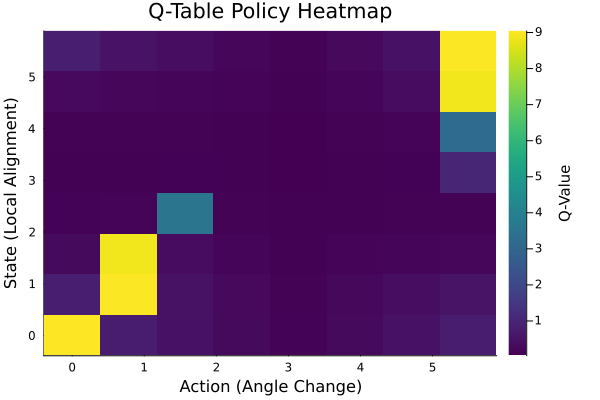

In [20]:
# Generate the heatmap
heatmap(
    actions,            # X-axis: The possible moves (Δθ)
    states,             # Y-axis: The discrete states (Δϕ)
    Q_rec,              # The 2D matrix data
    title="Q-Table Policy Heatmap",
    xlabel="Action (Angle Change)",
    ylabel="State (Local Alignment)",
    color=:viridis,     # A colorblind-friendly, high-contrast palette
    colorbar_title="Q-Value",
    aspect_ratio=:none, # Allows the plot to stretch to fill the frame
    right_margin=5Plots.mm # Prevents the colorbar from getting cut off
)

In [ ]:
plot(Φ)